In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

In [3]:
pause = pd.read_csv("data/Degron_PolII_pausing_ratio_with_metatadata_ENSGid.csv")

In [4]:
pause

,length,gene_id,gene.name,TSS,gene.body,condition,biotype,pausing_ratio,log2_pausing_ratio,baseMean_90min_0h,baseMean_8h_0h,promoter_type_NA,promoter_type_1,promoter_type_2,promoter_type_3,promoter_type_4,promoter_coordinate_1,promoter_coordinate_2,promoter_coordinate_3,promoter_coordinate_4
0,20653,ENSG00000187634,SAMD11,0.390980,0.572375,D8L4Y_0h,protein_coding,0.683084,-0.549866,0.781619,0.885234,no promoter information,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15107,ENSG00000188976,NOC2L,1.295441,0.358256,D8L4Y_0h,protein_coding,3.615969,1.854382,14.656974,14.042693,NaN,GC_box,NaN,NaN,NaN,chr1:959255-959256,NaN,NaN,NaN
2,5136,ENSG00000187961,KLHL17,0.528975,0.429036,D8L4Y_0h,protein_coding,1.232939,0.302102,1.290298,1.356666,NaN,GC_box,Initiator,NaN,NaN,chr1:960632-960633,chr1:960632-960633,NaN,NaN
3,9384,ENSG00000187583,PLEKHN1,2.165845,0.337327,D8L4Y_0h,protein_coding,6.420606,2.682710,2.074539,2.430391,NaN,GC_box,NaN,NaN,NaN,chr1:966481-966482,NaN,NaN,NaN
4,6920,ENSG00000187642,PERM1,0.356520,0.639117,D8L4Y_0h,protein_coding,0.557832,-0.842097,0.110897,0.070301,no promoter information,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49664,58447,ENSG00000155962,CLIC2,0.076530,0.064844,D8L4Y_90min,protein_coding,1.180211,0.239045,5.276680,5.985290,NaN,CCAAT,GC_box,NaN,NaN,chrX:155334558-155334559,chrX:155334558-155334559,NaN,NaN
49665,1707,ENSG00000288709,F8A2,0.660087,0.156158,D8L4Y_90min,protein_coding,4.227044,2.079649,0.000000,0.000000,no promoter information,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49666,169888,ENSG00000168939,SPRY3,0.672597,0.071619,D8L4Y_90min,protein_coding,9.391387,3.231338,6.589044,5.842758,NaN,Initiator,NaN,NaN,NaN,chrX:155612585-155612586,NaN,NaN,NaN
49667,62425,ENSG00000124333,VAMP7,0.875050,0.095509,D8L4Y_90min,protein_coding,9.161985,3.195660,0.007820,0.007820,no promoter information,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
pause["length"] = pause["length"]

print("Min pause length:", pause["length"].min())

Min pause length: 1004


In [ ]:
pause.query("TSS < 0.5").gene_id.unique()

array(['ENSG00000187634', 'ENSG00000187642', 'ENSG00000162571', ...,
       'ENSG00000226023', 'ENSG00000125676', 'ENSG00000155966'],
      dtype=object)

In [ ]:
low_tss_coverage_ids = pause.query("TSS < 0.5").gene_id.unique()
pause_good_tss = pause.query("gene_id not in @low_tss_coverage_ids")

In [ ]:
# new dataframe for plotting
pausing_ratio = pause_good_tss[
    [
        "length",
        "gene.name",
        "promoter_coordinate_1",
        "promoter_coordinate_2",
        "promoter_coordinate_3",
        "promoter_coordinate_4",
        "condition",
        "pausing_ratio",
    ]
].copy()

In [ ]:
# calculate log2 of pausing ratio for ECDF
pausing_ratio["log2_pausing_ratio"] = np.log2(pausing_ratio.pausing_ratio)

In [10]:
pausing_ratio.condition.unique()

array(['D8L4Y_0h', 'D8L4Y_8h', 'D8L4Y_90min'], dtype=object)

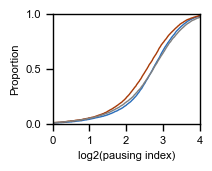

In [ ]:
# plot ECDF of log pausing ratiop for manuscript
sns.set_context("paper")

pal = sns.color_palette(["grey", "xkcd:rust", "xkcd:medium blue"])
condition_order = ["D8L4Y_0h", "D8L4Y_90min", "D8L4Y_8h"]

f, a = plt.subplots(figsize=(4, 1.8))

sns.ecdfplot(
    pausing_ratio,
    x="log2_pausing_ratio",
    hue="condition",
    hue_order=condition_order,
    palette=pal,
    linewidth=1,
    legend=False,
)

a.set_box_aspect(0.75)

a.set_xlim(0, 4)
a.set_xlabel("log2(pausing index)", fontsize=8)

a.set_ylabel("Proportion", fontsize=8)
a.set_yticks([0, 0.5, 1])

a.tick_params(axis="both", labelsize=8)

plt.tight_layout()

plt.savefig("pausing_ratio_ECDF_0_1p5_8hr_TSSabovep5.svg")